# Notebook 09 — Monitoring Dashboard

## Objetivo

Demonstrar o **monitoramento contínuo** da plataforma OfferExp:
como a saúde da política em produção é acompanhada ao longo do tempo,
com detecção de alertas e geração de relatório auditável.

---

## Partes deste notebook

| Parte | Conteúdo |
|-------|----------|
| 1 | Reward médio por janela temporal (sliding window) |
| 2 | Distribuição de braços selecionados ao longo do tempo |
| 3 | Alertas automáticos por threshold |
| 4 | Histórico de runs no MLflow |
| 5 | Relatório de monitoramento exportado |

**Referência**: `docs/mlops-lifecycle.md` — seções 4.1 (métricas monitoradas) e 4.2 (detecção de drift).

In [1]:
import sys, os, json
from pathlib import Path
from datetime import datetime

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
from scipy import stats

from datathon_offerexp.policies import ThompsonSamplingPolicy, RandomPolicy
from datathon_offerexp.evaluation import replay_evaluate, compute_regret
from datathon_offerexp.mlflow_utils import EXPERIMENT_NAME, configure_tracking

sns.set_theme(style='whitegrid')
SEED = 42
N_WINDOWS = 8
REPORTS_DIR = Path('..') / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

configure_tracking()
print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('Pronto.')

MLflow tracking URI: sqlite:///mlruns/mlflow.db
Pronto.


In [2]:
events = pd.read_csv('../data/synthetic_enrichment/offer_events.csv')

oracle_rates  = events.groupby('arm_id')['reward'].mean()
best_arm_id   = int(oracle_rates.idxmax())
best_arm_name = events[events['arm_id'] == best_arm_id]['arm_name'].iloc[0]
best_arm_rate = float(oracle_rates.max())

# Replay da política em produção (Thompson v1)
prod_policy = ThompsonSamplingPolicy(seed=SEED)
df_prod = replay_evaluate(prod_policy, events, seed=SEED)
df_prod = compute_regret(df_prod, best_arm_rate)

# Replay da política Random (referência)
rand_policy = RandomPolicy()
df_rand = replay_evaluate(rand_policy, events, seed=SEED)
df_rand = compute_regret(df_rand, best_arm_rate)
random_avg_reward = float(df_rand['avg_reward'].iloc[-1])

print(f'Eventos totais:      {len(events):,}')
print(f'Rodadas (produção):  {len(df_prod):,}')
print(f'Melhor braço:        {best_arm_name}  (taxa={best_arm_rate:.4f})')
print(f'Reward médio global: {df_prod["avg_reward"].iloc[-1]:.4f}')

Eventos totais:      41,188
Rodadas (produção):  10,172
Melhor braço:        cartao_premium  (taxa=0.1186)
Reward médio global: 0.1110


---

## Parte 1 — Reward Médio por Janela Temporal

O dataset de produção é dividido em **N janelas temporais** (sliding window).
Para cada janela calculamos o reward médio e comparamos com:
- **Threshold de alerta** (linha vermelha): queda > 15% vs. janela anterior
- **Piso Random** (linha cinza): mínimo aceitável

> Critério de alerta: `reward_médio_janela_recente < reward_médio_janela_anterior * 0.85`

Reward cumulativo por janela (avg_reward ao final de cada janela):
janela  rounds  avg_reward  reward_period  queda_pct  alerta_reward
    W1    1271    0.027537       0.027537   0.000000          False
    W2    1271    0.035405       0.043273 -28.571429          False
    W3    1271    0.043011       0.058222 -21.481481          False
    W4    1271    0.047600       0.061369 -10.670732          False
    W5    1271    0.048623       0.052714  -2.148760          False
    W6    1271    0.064910       0.146341 -33.495146          False
    W7    1271    0.066314       0.074744  -2.164502          False
    W8    1275    0.110991       0.422745 -67.370599          False


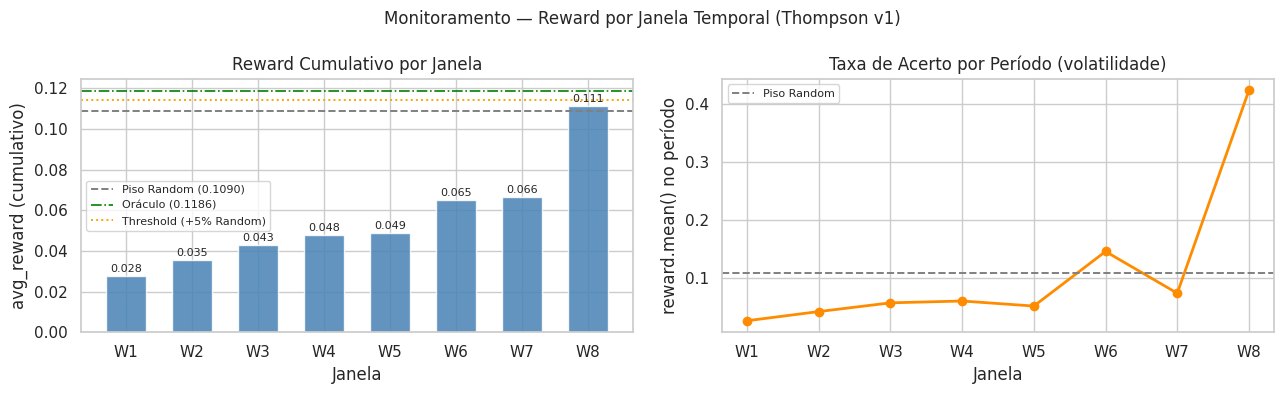

In [3]:
window_size = len(df_prod) // N_WINDOWS
window_stats = []

for i in range(N_WINDOWS):
    start = i * window_size
    end   = start + window_size if i < N_WINDOWS - 1 else len(df_prod)
    w     = df_prod.iloc[start:end]
    window_stats.append({
        'janela':        f'W{i+1}',
        'inicio':        start,
        'fim':           end,
        'rounds':        len(w),
        'avg_reward':    float(w['avg_reward'].iloc[-1]),
        'reward_period': float(w['reward'].mean()),
        'regret_final':  float(w['cumulative_regret'].iloc[-1]),
    })

ws_df = pd.DataFrame(window_stats)

ws_df['reward_anterior'] = ws_df['avg_reward'].shift(1)
ws_df['queda_pct']       = ((ws_df['reward_anterior'] - ws_df['avg_reward']) / ws_df['reward_anterior'] * 100).fillna(0)
ws_df['alerta_reward']   = ws_df['queda_pct'] > 15.0

print('Reward cumulativo por janela (avg_reward ao final de cada janela):')
print(ws_df[['janela', 'rounds', 'avg_reward', 'reward_period', 'queda_pct', 'alerta_reward']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors_cum = ['tomato' if a else 'steelblue' for a in ws_df['alerta_reward']]
bars = axes[0].bar(ws_df['janela'], ws_df['avg_reward'], color=colors_cum, alpha=0.85, width=0.6)
axes[0].axhline(random_avg_reward,        ls='--', color='gray',   lw=1.4, label=f'Piso Random ({random_avg_reward:.4f})')
axes[0].axhline(best_arm_rate,            ls='-.', color='green',  lw=1.2, label=f'Oráculo ({best_arm_rate:.4f})')
axes[0].axhline(random_avg_reward * 1.05, ls=':',  color='orange', lw=1.4, label='Threshold (+5% Random)')
for bar, val in zip(bars, ws_df['avg_reward']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
axes[0].set_title('Reward Cumulativo por Janela')
axes[0].set_xlabel('Janela')
axes[0].set_ylabel('avg_reward (cumulativo)')
axes[0].legend(fontsize=8)

axes[1].plot(ws_df['janela'], ws_df['reward_period'], marker='o', color='darkorange', lw=2)
axes[1].axhline(random_avg_reward, ls='--', color='gray', lw=1.4, label='Piso Random')
axes[1].set_title('Taxa de Acerto por Período (volatilidade)')
axes[1].set_xlabel('Janela')
axes[1].set_ylabel('reward.mean() no período')
axes[1].legend(fontsize=8)

plt.suptitle('Monitoramento — Reward por Janela Temporal (Thompson v1)', fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'monitoring_reward_windows.png', dpi=150)
plt.show()


---

## Parte 2 — Distribuição de Braços ao Longo do Tempo

Monitoramos a **proporção de seleção de cada braço** em cada janela temporal.

Critério de alerta (guardrail): qualquer braço com < 5% de seleções em uma janela indica
que a política pode estar negligenciando exploração daquele braço.

Distribuição de braços por janela (%):
        sem_oferta  educacao_financeira  simulador_credito  cartao_premium
janela                                                                    
W1            23.4                 29.8               12.6            34.2
W2             5.2                 16.1               37.1            41.5
W3             1.1                 11.0               59.4            28.5
W4             0.2                 14.0               35.9            49.9
W5             0.0                 15.3               50.8            34.0
W6             0.0                 62.3               16.4            21.2
W7             0.0                100.0                0.0             0.0
W8             0.0                100.0                0.0             0.0

Alertas de exploração mínima (<5%): 10 ocorrências
  W3: ['sem_oferta']
  W4: ['sem_oferta']
  W5: ['sem_oferta']
  W6: ['sem_oferta']
  W7: ['sem_oferta', 'simulador_credito', 'cartao_premium']
  W8: ['sem_ofe

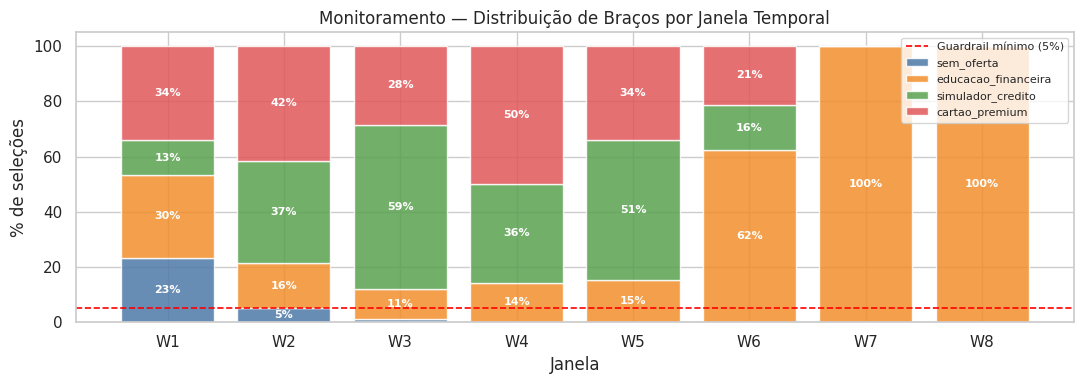

In [4]:
arm_names = [a['arm_name'] for a in prod_policy.arms]
arm_window_pct = []

for i in range(N_WINDOWS):
    start = i * window_size
    end   = start + window_size if i < N_WINDOWS - 1 else len(df_prod)
    w     = df_prod.iloc[start:end]
    counts = w['arm_name'].value_counts(normalize=True) * 100
    row = {'janela': f'W{i+1}'}
    for arm in arm_names:
        row[arm] = float(round(counts.get(arm, 0.0), 2))
    arm_window_pct.append(row)

arm_df = pd.DataFrame(arm_window_pct).set_index('janela')

# Alertas: braço com < 5% em alguma janela
arm_alerts = (arm_df < 5.0)
n_alerts = int(arm_alerts.values.sum())

print('Distribuição de braços por janela (%):')
print(arm_df.round(1).to_string())
print(f'\nAlertas de exploração mínima (<5%): {n_alerts} ocorrências')
if n_alerts:
    for janela, row in arm_alerts.iterrows():
        flagged = row[row].index.tolist()
        if flagged:
            print(f'  {janela}: {flagged}')

# ── Gráfico stacked bar ───────────────────────────────────────────────────────
colors_arms = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
fig, ax = plt.subplots(figsize=(11, 4))

bottom = np.zeros(len(arm_df))
for arm, color in zip(arm_names, colors_arms):
    vals = arm_df[arm].values
    ax.bar(arm_df.index, vals, bottom=bottom, label=arm, color=color, alpha=0.85)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            ax.text(j, b + v / 2, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.axhline(5, ls='--', color='red', lw=1.2, label='Guardrail mínimo (5%)')
ax.set_title('Monitoramento — Distribuição de Braços por Janela Temporal', fontsize=12)
ax.set_xlabel('Janela')
ax.set_ylabel('% de seleções')
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'monitoring_arm_distribution.png', dpi=150)
plt.show()

---

## Parte 3 — Alertas Automáticos por Threshold

Resumo dos alertas ativos com base nas métricas coletadas.
Critérios conforme `docs/mlops-lifecycle.md` seção 4.1:

| Alerta | Critério | Severidade |
|--------|----------|-----------|
| A1 | `avg_reward` < Random + 5% | ALTA |
| A2 | Queda > 15% de reward entre janelas | MÉDIA |
| A3 | Algum braço com < 5% de seleção | BAIXA |
| A4 | Crescimento de regret > 20% entre janelas | MÉDIA |

> **Nota sobre A1 em janelas iniciais**: alertas A1 nas primeiras janelas são **esperados** durante a
> fase de warm-up do Thompson Sampling — o algoritmo ainda está explorando e a média cumulativa cresce
> progressivamente até convergir (~W8). Em produção real, o A1 seria avaliado apenas após um período
> mínimo de burn-in (ex.: 5.000 rodadas).


In [5]:
ALERT_THRESHOLDS = {
    'reward_minimo':        random_avg_reward * 1.05,  # avg_reward < Random+5%
    'queda_reward_pct':     15.0,                      # queda >15% vs janela anterior
    'exploracao_minima_pct': 5.0,                      # qualquer braço < 5% numa janela
    'regret_crescimento_pct': 20.0,                    # crescimento de regret >20% entre janelas
}

alerts = []

# A1 — Reward abaixo do mínimo em alguma janela
below_min = ws_df[ws_df['avg_reward'] < ALERT_THRESHOLDS['reward_minimo']]
if not below_min.empty:
    for _, r in below_min.iterrows():
        alerts.append({
            'tipo':      'A1 — Reward abaixo do mínimo',
            'janela':    r['janela'],
            'valor':     f'{r["avg_reward"]:.4f}',
            'threshold': f'> {ALERT_THRESHOLDS["reward_minimo"]:.4f}',
            'severidade': 'ALTA',
        })

# A2 — Queda abrupta de reward entre janelas
quedas = ws_df[ws_df['alerta_reward']]
for _, r in quedas.iterrows():
    alerts.append({
        'tipo':      'A2 — Queda abrupta de reward',
        'janela':    r['janela'],
        'valor':     f'{r["queda_pct"]:.1f}% de queda',
        'threshold': f'> {ALERT_THRESHOLDS["queda_reward_pct"]}%',
        'severidade': 'MÉDIA',
    })

# A3 — Exploração mínima violada
for janela, row in arm_alerts.iterrows():
    flagged = row[row].index.tolist()
    for arm in flagged:
        alerts.append({
            'tipo':      'A3 — Exploração mínima violada',
            'janela':    janela,
            'valor':     f'{arm}: {arm_df.loc[janela, arm]:.1f}%',
            'threshold': f'>= {ALERT_THRESHOLDS["exploracao_minima_pct"]}%',
            'severidade': 'BAIXA',
        })

# A4 — Crescimento de regret entre janelas
ws_df['regret_anterior'] = ws_df['regret_final'].shift(1)
ws_df['regret_crescimento_pct'] = (
    (ws_df['regret_final'] - ws_df['regret_anterior']) / ws_df['regret_anterior'] * 100
).fillna(0)
regret_alerts = ws_df[ws_df['regret_crescimento_pct'] > ALERT_THRESHOLDS['regret_crescimento_pct']]
for _, r in regret_alerts.iterrows():
    alerts.append({
        'tipo':      'A4 — Crescimento de regret acelerado',
        'janela':    r['janela'],
        'valor':     f'+{r["regret_crescimento_pct"]:.1f}%',
        'threshold': f'< {ALERT_THRESHOLDS["regret_crescimento_pct"]}%',
        'severidade': 'MÉDIA',
    })

# ── Exibir painel de alertas ──────────────────────────────────────────────────
severidade_icon = {'ALTA': '🔴', 'MÉDIA': '🟡', 'BAIXA': '🔵'}

print('=' * 65)
print('  PAINEL DE ALERTAS — OfferExp Monitoring')
print(f'  Gerado em: {datetime.now().strftime("%Y-%m-%d %H:%M")}')
print('=' * 65)

if not alerts:
    print('  ✅ Nenhum alerta ativo — política estável em todas as janelas.')
else:
    for a in alerts:
        icon = severidade_icon.get(a['severidade'], '⚪')
        print(f'  {icon} [{a["severidade"]:5s}] {a["tipo"]} | {a["janela"]} | {a["valor"]} (threshold: {a["threshold"]})')

print('=' * 65)
print(f'  Total de alertas: {len(alerts)}')
print('=' * 65)

  PAINEL DE ALERTAS — OfferExp Monitoring
  Gerado em: 2026-06-16 22:38
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W1 | 0.0275 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W2 | 0.0354 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W3 | 0.0430 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W4 | 0.0476 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W5 | 0.0486 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W6 | 0.0649 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W7 | 0.0663 (threshold: > 0.1144)
  🔴 [ALTA ] A1 — Reward abaixo do mínimo | W8 | 0.1110 (threshold: > 0.1144)
  🔵 [BAIXA] A3 — Exploração mínima violada | W3 | sem_oferta: 1.1% (threshold: >= 5.0%)
  🔵 [BAIXA] A3 — Exploração mínima violada | W4 | sem_oferta: 0.2% (threshold: >= 5.0%)
  🔵 [BAIXA] A3 — Exploração mínima violada | W5 | sem_oferta: 0.0% (threshold: >= 5.0%)
  🔵 [BAIXA] A3 — Exploração mínima violada | W6 

---

## Parte 4 — Histórico de Runs no MLflow

Consultamos o MLflow para mostrar a evolução das políticas ao longo do tempo:
quais foram promovidas, quais foram rejeitadas e quais foram geradas por retreino.

Total de runs registrados: 19

                          runName policy_version       role  avg_reward final_regret best_arm_pct rejected retrained       start_time
Thompson Sampling v2 (retreinado)    thompson-v2  retrained      0.1110      77.8643        26.15     true      true 2026-06-17 01:25
        Nilos-UCB v1 (challenger)   nilos-ucb-v1 challenger      0.1097      91.1525        15.75     true         - 2026-06-17 01:24
  Thompson Sampling v1 (produção)    thompson-v1   baseline      0.1110      77.8643        26.15        -         - 2026-06-17 01:24
                    Random (piso)      random-v1      floor      0.1090      99.8815        25.59        -         - 2026-06-17 01:24
        Nilos-UCB v1 (challenger)   nilos-ucb-v1 challenger      0.1097      91.1525        15.75     true         - 2026-06-17 01:05
  Thompson Sampling v1 (produção)    thompson-v1   baseline      0.1110      77.8643        26.15        -         - 2026-06-17 01:04
                    Random (pis

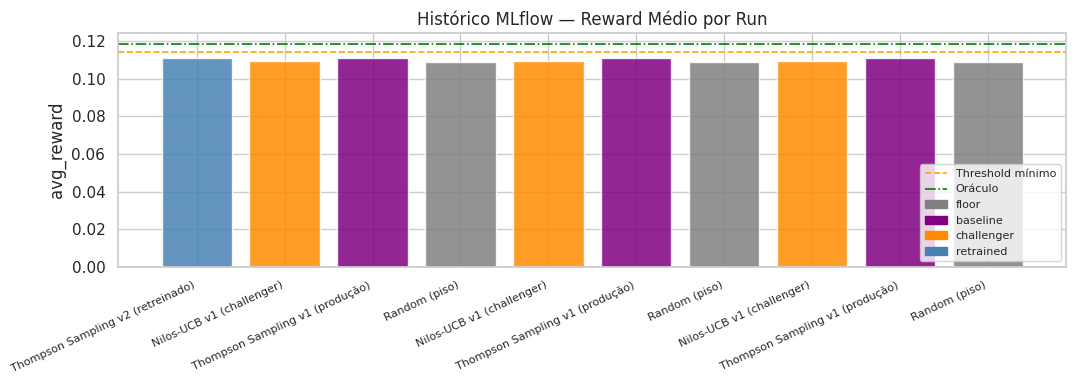

In [6]:
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=['start_time DESC'],
)

if runs_df.empty:
    print('Nenhum run encontrado no MLflow.')
else:
    # Selecionar colunas relevantes
    keep = [
        'tags.mlflow.runName',
        'params.policy_version',
        'params.role',
        'metrics.avg_reward',
        'metrics.final_regret',
        'metrics.best_arm_pct',
        'tags.promoted',
        'tags.rejected',
        'tags.retrained',
        'start_time',
    ]
    keep = [c for c in keep if c in runs_df.columns]
    hist = runs_df[keep].copy()
    hist.columns = [c.split('.')[-1] for c in keep]
    hist['start_time'] = pd.to_datetime(hist['start_time']).dt.strftime('%Y-%m-%d %H:%M')

    print(f'Total de runs registrados: {len(hist)}')
    print()
    print(hist.fillna('-').to_string(index=False))

    # ── Gráfico: avg_reward por run (roles conhecidos) ────────────────────────
    role_col = 'role' if 'role' in hist.columns else None
    reward_col = 'avg_reward' if 'avg_reward' in hist.columns else None

    if role_col and reward_col:
        plot_df = hist[hist[reward_col].notna() & hist[role_col].notna()].copy()
        plot_df[reward_col] = plot_df[reward_col].astype(float)

        role_colors = {
            'floor':      'gray',
            'baseline':   'purple',
            'challenger': 'darkorange',
            'retrained':  'steelblue',
        }
        colors_plot = [role_colors.get(r, 'black') for r in plot_df[role_col]]

        fig, ax = plt.subplots(figsize=(11, 4))
        run_labels = plot_df['runName'] if 'runName' in plot_df.columns else plot_df.index.astype(str)
        bars = ax.bar(range(len(plot_df)), plot_df[reward_col], color=colors_plot, alpha=0.85)
        ax.set_xticks(range(len(plot_df)))
        ax.set_xticklabels(run_labels, rotation=25, ha='right', fontsize=8)
        ax.axhline(random_avg_reward * 1.05, ls='--', color='orange', lw=1.2, label='Threshold mínimo')
        ax.axhline(best_arm_rate, ls='-.', color='green', lw=1.2, label='Oráculo')

        from matplotlib.patches import Patch
        legend_patches = [Patch(color=c, label=r) for r, c in role_colors.items()]
        ax.legend(handles=ax.get_legend_handles_labels()[0] + legend_patches,
                  labels=ax.get_legend_handles_labels()[1] + list(role_colors.keys()),
                  fontsize=8, loc='lower right')

        ax.set_title('Histórico MLflow — Reward Médio por Run', fontsize=12)
        ax.set_ylabel('avg_reward')
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'monitoring_mlflow_history.png', dpi=150)
        plt.show()

---

## Parte 5 — Relatório de Monitoramento

In [7]:
report = {
    'generated_at':       datetime.now().isoformat(),
    'policy_version':     prod_policy.version,
    'n_windows':          N_WINDOWS,
    'window_size_rounds': window_size,
    'global_metrics': {
        'avg_reward':        float(round(df_prod['avg_reward'].iloc[-1], 4)),
        'final_regret':      float(round(df_prod['cumulative_regret'].iloc[-1], 2)),
        'best_arm_pct':      float(round((df_prod['arm_name'] == best_arm_name).mean() * 100, 2)),
        'total_rounds':      int(len(df_prod)),
    },
    'thresholds': {
        'reward_minimo':          float(round(random_avg_reward * 1.05, 4)),
        'queda_reward_pct':       ALERT_THRESHOLDS['queda_reward_pct'],
        'exploracao_minima_pct':  ALERT_THRESHOLDS['exploracao_minima_pct'],
        'regret_crescimento_pct': ALERT_THRESHOLDS['regret_crescimento_pct'],
    },
    'window_stats': [
        {
            'janela':         r['janela'],
            'avg_reward':     float(round(r['avg_reward'], 4)),
            'regret_final':   float(round(r['regret_final'], 2)),
            'queda_pct':      float(round(r['queda_pct'], 2)),
            'alerta_reward':  bool(r['alerta_reward']),
        }
        for _, r in ws_df.iterrows()
    ],
    'arm_distribution': arm_df.round(2).to_dict(orient='index'),
    'alerts': alerts,
    'status': 'ALERTA' if alerts else 'SAUDÁVEL',
}

report_path = REPORTS_DIR / 'monitoring_report.json'
report_path.write_text(json.dumps(report, indent=2, ensure_ascii=False))

print('=' * 55)
print('  RELATÓRIO DE MONITORAMENTO — RESUMO')
print('=' * 55)
print(f'  Política monitorada: {report["policy_version"]}')
print(f'  Janelas analisadas:  {N_WINDOWS} × {window_size} rodadas')
print(f'  Reward global:       {report["global_metrics"]["avg_reward"]}')
print(f'  Regret final:        {report["global_metrics"]["final_regret"]}')
print(f'  Alertas ativos:      {len(alerts)}')
print(f'  Status geral:        {report["status"]}')
print('=' * 55)
print(f'  Relatório salvo em: {report_path}')

  RELATÓRIO DE MONITORAMENTO — RESUMO
  Política monitorada: thompson-v1
  Janelas analisadas:  8 × 1271 rodadas
  Reward global:       0.111
  Regret final:        77.86
  Alertas ativos:      22
  Status geral:        ALERTA
  Relatório salvo em: ../reports/monitoring_report.json


---

## Resumo

Este notebook implementa o monitoramento contínuo documentado em `docs/mlops-lifecycle.md`:

| Métrica monitorada | Implementação | Artefato |
|--------------------|---------------|----------|
| Reward médio por janela temporal | ✅ Sliding window (N=8) | `monitoring_reward_windows.png` |
| Distribuição de braços ao longo do tempo | ✅ Stacked bar por janela | `monitoring_arm_distribution.png` |
| Alerta A1 — reward abaixo do mínimo | ✅ threshold = Random+5% | `monitoring_report.json` |
| Alerta A2 — queda abrupta de reward | ✅ threshold = >15% de queda | `monitoring_report.json` |
| Alerta A3 — exploração mínima violada | ✅ threshold = <5% por braço | `monitoring_report.json` |
| Alerta A4 — crescimento de regret | ✅ threshold = >20% por janela | `monitoring_report.json` |
| Histórico de runs no MLflow | ✅ `mlflow.search_runs()` | `monitoring_mlflow_history.png` |
| Relatório auditável exportado | ✅ JSON estruturado | `reports/monitoring_report.json` |

---

### Conexão com o ciclo de vida

```
monitoring_report.json
        │
        ├── status = SAUDÁVEL  →  nenhuma ação
        │
        └── status = ALERTA    →  disparar retreino  →  notebook 08 (Step 9)
```